# WavLM Speech Classification — 16-bit then 1-bit, cell by cell

**Reference architecture:** Chen et al., *"WavLM: Large-Scale Self-Supervised Pre-Training for
Full Stack Speech Processing"* (IEEE J-STSP, 2022).

## How WavLM differs from wav2vec 2.0 (why it's not just a drop-in rename)

Both models share the same front end — a 7-layer 1-D CNN **feature encoder** turning raw 16 kHz
audio into ~50 Hz latent frames — so the input-normalization concerns from the wav2vec2 notebook
apply identically here. The differences that matter for fine-tuning are inside the Transformer:

1. **Pretraining objective.** wav2vec2 uses a contrastive loss against quantized targets. WavLM
   uses **masked speech denoising prediction** (HuBERT-style masked pseudo-label prediction), but
   critically the *input* during pretraining is corrupted with **simulated overlapping speech and
   noise** ("utterance mixing"). The model has to predict the pseudo-labels of the *original,
   clean, primary* speaker even when a second, unrelated utterance has been mixed in. This is the
   "full stack" part of the name — it's explicitly trained to be robust to interference, which is
   directly relevant to a noisy/degraded input condition like your 1-bit branch.
2. **Gated relative position bias** in the Transformer's self-attention (an extension of
   Transformer-XL-style relative position encoding with an added learned gate), replacing
   wav2vec2's convolutional relative-position embedding. This tends to help WavLM more on tasks
   sensitive to speaker/prosody/timing structure — plausibly relevant to a Command vs
   Conversation vs Read vs Numeric distinction, which is partly a prosody/rhythm classification
   problem.
3. **Checkpoint used here:** `microsoft/wavlm-base-plus` — pretrained on ~94k hours of mixed data
   (Libri-Light + GigaSpeech + VoxPopuli), same parameter count class as `wav2vec2-base` (~95M
   params) so the comparison to your earlier wav2vec2 run stays apples-to-apples on model size.

## Everything carried over from the wav2vec2 pipeline, plus two new fixes from your last run

- Proper input normalization matching the checkpoint's feature extractor (`do_normalize`).
- Seeded reproducibility, layer-weighted-sum pooling head (not last-layer-only), leakage check,
  identical stage schedule across both bit-depth conditions, MFCC baseline, bootstrap CI +
  McNemar test.
- **New: automatic train/test de-duplication.** Your 1-bit run found one exact-duplicate
  waveform shared between train and test. This notebook now actively removes any training
  sample whose waveform hash collides with anything in val or test, for both conditions, and
  prints how many were removed — instead of just flagging it and leaving you to fix it by hand.
- **New: a note on execution order.** Run this with `Kernel → Restart & Run All` in one pass.
  Your wav2vec2 notebook's execution counters showed several out-of-order re-runs during the
  1-bit stages, which made one reported "best val acc" untraceable to any printed epoch. Keep
  this one clean so every number in the output can be traced to a specific cell run.

As before: I have not run this myself (no GPU / no dataset here), so no output numbers below are
real — run it and report what actually comes out.


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/y_train.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/y_test.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/y_val.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/X_test.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/X_val.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/X_train.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/y_1bit_test.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/X_1bit_test.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/y_1bit_val.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/y_1bit_train.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/X_1bit_val.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/X_1bit_train.npy


In [3]:
# ============================================================
# Shared Setup — 0. Environment
# ============================================================
!pip install -q transformers==4.44.2 accelerate scikit-learn scipy librosa


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 73.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 67.1 MB/s eta 0:00:00:00:01


In [4]:
# ============================================================
# Shared Setup — 1. Imports & Reproducibility
# ============================================================
import os
import gc
import copy
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import WavLMModel, Wav2Vec2FeatureExtractor, get_cosine_schedule_with_warmup
# NOTE: WavLM uses the SAME feature-extractor class as wav2vec2 (Wav2Vec2FeatureExtractor) —
# there is no separate "WavLMFeatureExtractor"; the preprocessing contract (raw waveform,
# optional zero-mean/unit-variance normalization) is identical.

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
)
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from scipy.stats import chi2
import librosa


def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [5]:
# ============================================================
# Shared Setup — 2. Config
# ============================================================
SR = 16000
N_SAMPLES = 16000
NUM_CLASSES = 4
CLASS_NAMES = ["Command", "Conversation", "Numeric", "Read"]

PRETRAINED_CKPT = "microsoft/wavlm-base-plus"

BATCH_SIZE = 8
NUM_WORKERS = 2

# Same stage schedule used for both conditions, and the SAME schedule you used for wav2vec2 —
# keeping this identical across model architectures and bit-depths is what makes a WavLM-vs-
# wav2vec2 comparison fair (any difference reflects the pretrained representation, not the
# training recipe).
STAGES = [
    # (n_unfrozen_top_layers, max_epochs, lr, patience)
    (0, 8, 1e-4, 3),
    (4, 10, 1e-5, 4),
    (8, 8, 5e-6, 4),
]

WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0
WARMUP_RATIO = 0.1
LABEL_SMOOTHING = 0.05
USE_AMP = True

DATA16_DIR = "/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit"
DATA1_DIR = "/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit"

OUT_DIR = "/kaggle/working/results_wavlm"
os.makedirs(OUT_DIR, exist_ok=True)

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(PRETRAINED_CKPT)
print("Feature extractor do_normalize:", feature_extractor.do_normalize)


preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Feature extractor do_normalize: False


In [6]:
# ============================================================
# Shared Setup — 3. Dataset / leakage-check-and-fix / describe utilities
# ============================================================
def load_split(data_dir, x_name, y_name):
    X = np.load(os.path.join(data_dir, x_name))
    y = np.load(os.path.join(data_dir, y_name))
    return X, y


def describe_dataset(name, X_train, y_train, X_val, y_val, X_test, y_test):
    print("=" * 60)
    print(f"Dataset: {name}")
    print("=" * 60)
    print("Train:", X_train.shape, y_train.shape)
    print("Val  :", X_val.shape, y_val.shape)
    print("Test :", X_test.shape, y_test.shape)
    print("dtype:", X_train.dtype, "| min:", X_train.min(), "| max:", X_train.max())
    for split_name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
        u, c = np.unique(y, return_counts=True)
        dist = {CLASS_NAMES[i]: int(cnt) for i, cnt in zip(u, c)}
        print(f"{split_name} class distribution: {dist}")


def _waveform_hashes(X):
    Xf = np.squeeze(X).astype(np.float32)
    return [hash(Xf[i].tobytes()) for i in range(len(Xf))]


def check_leakage(X_train, X_val, X_test):
    """Flags exact-duplicate waveforms shared across splits."""
    h_train, h_val, h_test = set(_waveform_hashes(X_train)), set(_waveform_hashes(X_val)), set(_waveform_hashes(X_test))
    lv, lt, vt = h_train & h_val, h_train & h_test, h_val & h_test
    print(f"Duplicate waveforms train∩val : {len(lv)}")
    print(f"Duplicate waveforms train∩test: {len(lt)}")
    print(f"Duplicate waveforms val∩test  : {len(vt)}")
    if lv or lt or vt:
        warnings.warn("Data leakage detected — will be removed from the TRAIN split below.")
    return lv, lt, vt


def dedupe_train_against_val_test(X_train, y_train, X_val, X_test, tag: str):
    """Removes any training sample whose waveform hash also appears in val or test.
    This is the fix for the exact issue found in the earlier wav2vec2 1-bit run
    (1 duplicate waveform shared between train and test)."""
    h_train = _waveform_hashes(X_train)
    h_blocked = set(_waveform_hashes(X_val)) | set(_waveform_hashes(X_test))
    keep_mask = np.array([h not in h_blocked for h in h_train])
    n_removed = int((~keep_mask).sum())
    if n_removed > 0:
        print(f"[{tag}] Removed {n_removed} train sample(s) that duplicated a val/test waveform.")
    else:
        print(f"[{tag}] No train/val/test duplicate waveforms found — nothing removed.")
    return X_train[keep_mask], y_train[keep_mask]


class SpeechDataset(Dataset):
    """Applies the SAME normalization the pretrained checkpoint's feature
    extractor expects (zero-mean/unit-variance when `do_normalize=True`)."""

    def __init__(self, X, y, feature_extractor, augment: bool = False):
        X = np.squeeze(X, axis=-1) if X.ndim == 3 else X
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)
        self.fe = feature_extractor
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def _normalize(self, wav):
        if self.fe.do_normalize:
            wav = (wav - wav.mean()) / (wav.std() + 1e-7)
        return wav

    def _augment(self, wav):
        if random.random() < 0.5:
            wav = wav * random.uniform(0.85, 1.15)
        if random.random() < 0.3:
            wav = wav + np.random.normal(0, 0.003, size=wav.shape).astype(np.float32)
        return wav

    def __getitem__(self, idx):
        wav = self.X[idx].copy()
        if self.augment:
            wav = self._augment(wav)
        wav = self._normalize(wav)
        return torch.tensor(wav, dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)


def make_loaders(X_train, y_train, X_val, y_val, X_test, y_test):
    train_ds = SpeechDataset(X_train, y_train, feature_extractor, augment=True)
    val_ds = SpeechDataset(X_val, y_val, feature_extractor, augment=False)
    test_ds = SpeechDataset(X_test, y_test, feature_extractor, augment=False)

    class_counts = np.bincount(y_train.astype(int), minlength=NUM_CLASSES)
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights[y_train.astype(int)]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                               num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)
    return train_loader, val_loader, test_loader


In [7]:
# ============================================================
# Shared Setup — 4. Model definition (WavLM backbone)
# ============================================================
class WavLMClassifier(nn.Module):
    """Backbone: pretrained WavLMModel (CNN feature encoder + Transformer with
    gated relative position bias), used with `output_hidden_states=True`.

    Head: identical design to the wav2vec2 notebook on purpose — a learned
    softmax-weighted sum across all Transformer layers, then attentive-mean + max
    pooling over time, then a small MLP. Keeping the head identical isolates the
    backbone (wav2vec2 vs WavLM) as the only variable when you compare the two
    notebooks' results.
    """

    def __init__(self, pretrained_ckpt: str, num_classes: int, dropout: float = 0.2):
        super().__init__()
        self.backbone = WavLMModel.from_pretrained(pretrained_ckpt)
        n_layers = self.backbone.config.num_hidden_layers + 1
        hidden = self.backbone.config.hidden_size

        self.layer_weights = nn.Parameter(torch.zeros(n_layers))
        self.attn_pool = nn.Linear(hidden, 1)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def freeze_all(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_top_layers(self, n: int):
        """Freeze everything, then unfreeze only the top-`n` Transformer layers
        (CNN feature encoder stays frozen throughout, matching standard fine-tuning
        practice for both wav2vec2 and WavLM)."""
        self.freeze_all()
        if n > 0:
            for layer in self.backbone.encoder.layers[-n:]:
                for p in layer.parameters():
                    p.requires_grad = True
        for p in self.classifier.parameters():
            p.requires_grad = True
        for p in [self.layer_weights, self.attn_pool.weight, self.attn_pool.bias]:
            p.requires_grad = True

    def forward(self, input_values, attention_mask=None):
        out = self.backbone(input_values=input_values, attention_mask=attention_mask,
                             output_hidden_states=True)
        hidden_states = torch.stack(out.hidden_states, dim=0)        # (L, B, T, H)
        weights = torch.softmax(self.layer_weights, dim=0).view(-1, 1, 1, 1)
        pooled_layers = (hidden_states * weights).sum(dim=0)         # (B, T, H)

        attn_scores = self.attn_pool(pooled_layers).squeeze(-1)
        attn_weights = torch.softmax(attn_scores, dim=-1).unsqueeze(-1)
        attn_vec = (pooled_layers * attn_weights).sum(dim=1)
        max_vec, _ = pooled_layers.max(dim=1)

        feat = torch.cat([attn_vec, max_vec], dim=-1)
        return self.classifier(feat)

    def trainable_param_summary(self):
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        return trainable, total


In [8]:
# ============================================================
# Shared Setup — 5. Train / eval / reporting utilities
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, scheduler=None):
    model.train()
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    running_loss, correct, total = 0.0, 0, 0

    for waveforms, labels in loader:
        waveforms, labels = waveforms.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(input_values=waveforms)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        if scheduler is not None:
            scheduler.step()

        running_loss += loss.item()
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, return_predictions=False):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_probs, all_labels = [], [], []

    for waveforms, labels in loader:
        waveforms, labels = waveforms.to(device), labels.to(device)
        logits = model(input_values=waveforms)
        loss = criterion(logits, labels)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        running_loss += loss.item()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if return_predictions:
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    loss_out, acc_out = running_loss / len(loader), correct / total
    if return_predictions:
        return (loss_out, acc_out, np.concatenate(all_preds),
                np.concatenate(all_probs), np.concatenate(all_labels))
    return loss_out, acc_out


def full_test_report(model, test_loader, tag: str):
    criterion = nn.CrossEntropyLoss()
    _, test_acc, preds, probs, labels = evaluate(model, test_loader, criterion, return_predictions=True)

    precision = precision_score(labels, preds, average="macro", zero_division=0)
    recall = recall_score(labels, preds, average="macro", zero_division=0)
    f1 = f1_score(labels, preds, average="macro", zero_division=0)

    labels_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))
    try:
        roc_auc = roc_auc_score(labels_bin, probs, average="macro", multi_class="ovr")
    except ValueError:
        roc_auc = float("nan")

    eers = []
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        try:
            eer = brentq(lambda x: 1.0 - x - interp1d(fpr, tpr)(x), 0.0, 1.0)
        except ValueError:
            eer = float("nan")
        eers.append(eer)
    eer = float(np.nanmean(eers))

    print("=" * 50)
    print(f"{tag} — Test Set Performance")
    print("=" * 50)
    print(f"Accuracy   : {test_acc:.4f}")
    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"F1 (macro) : {f1:.4f}")
    print(f"ROC-AUC    : {roc_auc:.4f}")
    print(f"EER        : {eer:.4f}\n")
    print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=4))

    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(f"Confusion Matrix — {tag}")
    plt.tight_layout()
    plt.show()

    return {"tag": tag, "accuracy": test_acc, "precision": precision, "recall": recall,
            "f1_macro": f1, "roc_auc": roc_auc, "eer": eer,
            "preds": preds, "probs": probs, "labels": labels}


def extract_mfcc_features(X, sr=SR, n_mfcc=20):
    X = np.squeeze(X)
    feats = []
    for i in range(len(X)):
        mfcc = librosa.feature.mfcc(y=X[i].astype(np.float32), sr=sr, n_mfcc=n_mfcc)
        feats.append(np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)]))
    return np.array(feats)


def run_mfcc_baseline(X_train, y_train, X_val, y_val, X_test, y_test, tag: str):
    Xtr = extract_mfcc_features(X_train)
    Xva = extract_mfcc_features(X_val)
    Xte = extract_mfcc_features(X_test)

    scaler = StandardScaler().fit(np.concatenate([Xtr, Xva], axis=0))
    Xtr, Xva, Xte = scaler.transform(Xtr), scaler.transform(Xva), scaler.transform(Xte)

    clf = LogisticRegression(max_iter=2000, multi_class="multinomial")
    clf.fit(np.concatenate([Xtr, Xva]), np.concatenate([y_train, y_val]))

    preds = clf.predict(Xte)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    print(f"[{tag}] MFCC + LogisticRegression baseline — Test Acc: {acc:.4f} | Macro-F1: {f1:.4f}")
    return {"tag": tag, "accuracy": acc, "macro_f1": f1}


def plot_history(history_rows, tag: str):
    h = pd.DataFrame(history_rows)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(h["global_epoch"], h["train_acc"], label="train")
    axes[0].plot(h["global_epoch"], h["val_acc"], label="val")
    axes[0].set_title(f"{tag} — Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(h["global_epoch"], h["train_loss"], label="train")
    axes[1].plot(h["global_epoch"], h["val_loss"], label="val")
    axes[1].set_title(f"{tag} — Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    return h


---
# PART A — 16-bit condition
---

In [9]:
# ============================================================
# [16-bit] 1. Load data + sanity checks + de-duplication
# ============================================================
X_train_16, y_train_16 = load_split(DATA16_DIR, "X_train.npy", "y_train.npy")
X_val_16, y_val_16 = load_split(DATA16_DIR, "X_val.npy", "y_val.npy")
X_test_16, y_test_16 = load_split(DATA16_DIR, "X_test.npy", "y_test.npy")

describe_dataset("16-bit", X_train_16, y_train_16, X_val_16, y_val_16, X_test_16, y_test_16)
check_leakage(X_train_16, X_val_16, X_test_16)
X_train_16, y_train_16 = dedupe_train_against_val_test(X_train_16, y_train_16, X_val_16, X_test_16, tag="16-bit")


Dataset: 16-bit
Train: (9600, 16000, 1) (9600,)
Val  : (1200, 16000, 1) (1200,)
Test : (1200, 16000, 1) (1200,)
dtype: float32 | min: -1.0 | max: 1.0
train class distribution: {'Command': 2400, 'Conversation': 2400, 'Numeric': 2400, 'Read': 2400}
val class distribution: {'Command': 300, 'Conversation': 300, 'Numeric': 300, 'Read': 300}
test class distribution: {'Command': 300, 'Conversation': 300, 'Numeric': 300, 'Read': 300}
Duplicate waveforms train∩val : 0
Duplicate waveforms train∩test: 0
Duplicate waveforms val∩test  : 0
[16-bit] No train/val/test duplicate waveforms found — nothing removed.


In [10]:
# ============================================================
# [16-bit] 2. DataLoaders
# ============================================================
train_loader_16, val_loader_16, test_loader_16 = make_loaders(
    X_train_16, y_train_16, X_val_16, y_val_16, X_test_16, y_test_16
)

waveforms, labels = next(iter(train_loader_16))
print("Waveforms:", waveforms.shape, waveforms.dtype)
print("Labels   :", labels.shape, labels.dtype)


Waveforms: torch.Size([8, 16000]) torch.float32
Labels   : torch.Size([8]) torch.int64


In [11]:
# ============================================================
# [16-bit] 3. Model
# ============================================================
seed_everything(SEED)
model_16bit = WavLMClassifier(PRETRAINED_CKPT, NUM_CLASSES).to(device)
criterion_16bit = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

best_val_acc_16 = 0.0
best_state_16 = None
history_16 = []
global_epoch_16 = 0


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Some weights of the model checkpoint at microsoft/wavlm-base-plus were not used when initializing WavLMModel: ['encoder.pos_conv_embed.conv.weight_g', 'encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing WavLMModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing WavLMModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of WavLMModel were not initialized from the model checkpoint at microsoft/wavlm-base-plus and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictio

In [12]:
# ============================================================
# [16-bit] 4. Stage 1 — classifier head only
# ============================================================
stage = 1
n_unfrozen, max_epochs, lr, patience = STAGES[stage - 1]

model_16bit.unfreeze_top_layers(n_unfrozen)
trainable, total = model_16bit.trainable_param_summary()
print(f"[16-bit] Stage {stage}: unfreeze last {n_unfrozen} layers | trainable {trainable:,} / {total:,}")

optimizer_16bit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_16bit.parameters()), lr=lr, weight_decay=WEIGHT_DECAY
)
n_steps = max_epochs * len(train_loader_16)
scheduler_16bit = get_cosine_schedule_with_warmup(
    optimizer_16bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_16bit, train_loader_16, optimizer_16bit, criterion_16bit, scheduler_16bit)
    va_loss, va_acc = evaluate(model_16bit, val_loader_16, criterion_16bit)
    global_epoch_16 += 1

    print(f"[16-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_16.append({"global_epoch": global_epoch_16, "stage": stage,
                        "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_16:
        best_val_acc_16 = va_acc
        best_state_16 = copy.deepcopy(model_16bit.state_dict())
        torch.save(best_state_16, os.path.join(OUT_DIR, "best_wavlm_16bit.pth"))
        patience_counter = 0
        print(f"  -> new best (Val Acc = {best_val_acc_16:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("  -> early stopping stage", stage)
            break

print(f"\n[16-bit] Stage 1 finished. Best Val Acc so far: {best_val_acc_16:.4f}")


[16-bit] Stage 1: unfreeze last 0 layers | trainable 1,184,274 / 95,566,210
[16-bit] Stage 1 Epoch 1/8 | Train Loss 0.9062 Acc 0.6901 | Val Loss 0.4789 Acc 0.9300
  -> new best (Val Acc = 0.9300)
[16-bit] Stage 1 Epoch 2/8 | Train Loss 0.4145 Acc 0.9214 | Val Loss 0.3519 Acc 0.9517
  -> new best (Val Acc = 0.9517)
[16-bit] Stage 1 Epoch 3/8 | Train Loss 0.3554 Acc 0.9461 | Val Loss 0.3153 Acc 0.9658
  -> new best (Val Acc = 0.9658)
[16-bit] Stage 1 Epoch 4/8 | Train Loss 0.3304 Acc 0.9571 | Val Loss 0.3108 Acc 0.9675
  -> new best (Val Acc = 0.9675)
[16-bit] Stage 1 Epoch 5/8 | Train Loss 0.3215 Acc 0.9629 | Val Loss 0.3020 Acc 0.9733
  -> new best (Val Acc = 0.9733)
[16-bit] Stage 1 Epoch 6/8 | Train Loss 0.3131 Acc 0.9670 | Val Loss 0.2923 Acc 0.9767
  -> new best (Val Acc = 0.9767)
[16-bit] Stage 1 Epoch 7/8 | Train Loss 0.3097 Acc 0.9676 | Val Loss 0.2926 Acc 0.9742
[16-bit] Stage 1 Epoch 8/8 | Train Loss 0.3057 Acc 0.9698 | Val Loss 0.2938 Acc 0.9733

[16-bit] Stage 1 finished. Be

In [13]:
# ============================================================
# [16-bit] 5. Stage 2 — unfreeze last 4 transformer layers
# ============================================================
stage = 2
n_unfrozen, max_epochs, lr, patience = STAGES[stage - 1]

model_16bit.load_state_dict(best_state_16)  # continue from best Stage-1 weights
model_16bit.unfreeze_top_layers(n_unfrozen)
trainable, total = model_16bit.trainable_param_summary()
print(f"[16-bit] Stage {stage}: unfreeze last {n_unfrozen} layers | trainable {trainable:,} / {total:,}")

optimizer_16bit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_16bit.parameters()), lr=lr, weight_decay=WEIGHT_DECAY
)
n_steps = max_epochs * len(train_loader_16)
scheduler_16bit = get_cosine_schedule_with_warmup(
    optimizer_16bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_16bit, train_loader_16, optimizer_16bit, criterion_16bit, scheduler_16bit)
    va_loss, va_acc = evaluate(model_16bit, val_loader_16, criterion_16bit)
    global_epoch_16 += 1

    print(f"[16-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_16.append({"global_epoch": global_epoch_16, "stage": stage,
                        "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_16:
        best_val_acc_16 = va_acc
        best_state_16 = copy.deepcopy(model_16bit.state_dict())
        torch.save(best_state_16, os.path.join(OUT_DIR, "best_wavlm_16bit.pth"))
        patience_counter = 0
        print(f"  -> new best (Val Acc = {best_val_acc_16:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("  -> early stopping stage", stage)
            break

print(f"\n[16-bit] Stage 2 finished. Best Val Acc so far: {best_val_acc_16:.4f}")


[16-bit] Stage 2: unfreeze last 4 layers | trainable 29,537,890 / 95,566,210
[16-bit] Stage 2 Epoch 1/10 | Train Loss 0.3069 Acc 0.9706 | Val Loss 0.2901 Acc 0.9733
[16-bit] Stage 2 Epoch 2/10 | Train Loss 0.2955 Acc 0.9739 | Val Loss 0.2780 Acc 0.9808
  -> new best (Val Acc = 0.9808)
[16-bit] Stage 2 Epoch 3/10 | Train Loss 0.2889 Acc 0.9761 | Val Loss 0.2654 Acc 0.9858
  -> new best (Val Acc = 0.9858)
[16-bit] Stage 2 Epoch 4/10 | Train Loss 0.2750 Acc 0.9821 | Val Loss 0.2581 Acc 0.9917
  -> new best (Val Acc = 0.9917)
[16-bit] Stage 2 Epoch 5/10 | Train Loss 0.2673 Acc 0.9850 | Val Loss 0.2551 Acc 0.9892
[16-bit] Stage 2 Epoch 6/10 | Train Loss 0.2651 Acc 0.9842 | Val Loss 0.2524 Acc 0.9917
[16-bit] Stage 2 Epoch 7/10 | Train Loss 0.2613 Acc 0.9861 | Val Loss 0.2488 Acc 0.9917
[16-bit] Stage 2 Epoch 8/10 | Train Loss 0.2574 Acc 0.9864 | Val Loss 0.2467 Acc 0.9917
  -> early stopping stage 2

[16-bit] Stage 2 finished. Best Val Acc so far: 0.9917


In [14]:
# ============================================================
# [16-bit] 6. Stage 3 — unfreeze last 8 transformer layers
# ============================================================
stage = 3
n_unfrozen, max_epochs, lr, patience = STAGES[stage - 1]

model_16bit.load_state_dict(best_state_16)  # continue from best Stage-2 weights
model_16bit.unfreeze_top_layers(n_unfrozen)
trainable, total = model_16bit.trainable_param_summary()
print(f"[16-bit] Stage {stage}: unfreeze last {n_unfrozen} layers | trainable {trainable:,} / {total:,}")

optimizer_16bit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_16bit.parameters()), lr=lr, weight_decay=WEIGHT_DECAY
)
n_steps = max_epochs * len(train_loader_16)
scheduler_16bit = get_cosine_schedule_with_warmup(
    optimizer_16bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_16bit, train_loader_16, optimizer_16bit, criterion_16bit, scheduler_16bit)
    va_loss, va_acc = evaluate(model_16bit, val_loader_16, criterion_16bit)
    global_epoch_16 += 1

    print(f"[16-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_16.append({"global_epoch": global_epoch_16, "stage": stage,
                        "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_16:
        best_val_acc_16 = va_acc
        best_state_16 = copy.deepcopy(model_16bit.state_dict())
        torch.save(best_state_16, os.path.join(OUT_DIR, "best_wavlm_16bit.pth"))
        patience_counter = 0
        print(f"  -> new best (Val Acc = {best_val_acc_16:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("  -> early stopping stage", stage)
            break

model_16bit.load_state_dict(best_state_16)
print(f"\n[16-bit] All stages finished. Best Validation Accuracy: {best_val_acc_16:.4f}")


[16-bit] Stage 3: unfreeze last 8 layers | trainable 57,891,506 / 95,566,210
[16-bit] Stage 3 Epoch 1/8 | Train Loss 0.2679 Acc 0.9841 | Val Loss 0.2533 Acc 0.9917
[16-bit] Stage 3 Epoch 2/8 | Train Loss 0.2596 Acc 0.9866 | Val Loss 0.2467 Acc 0.9925
  -> new best (Val Acc = 0.9925)
[16-bit] Stage 3 Epoch 3/8 | Train Loss 0.2521 Acc 0.9876 | Val Loss 0.2442 Acc 0.9933
  -> new best (Val Acc = 0.9933)
[16-bit] Stage 3 Epoch 4/8 | Train Loss 0.2484 Acc 0.9883 | Val Loss 0.2417 Acc 0.9933
[16-bit] Stage 3 Epoch 5/8 | Train Loss 0.2394 Acc 0.9898 | Val Loss 0.2381 Acc 0.9917
[16-bit] Stage 3 Epoch 6/8 | Train Loss 0.2390 Acc 0.9908 | Val Loss 0.2369 Acc 0.9925
[16-bit] Stage 3 Epoch 7/8 | Train Loss 0.2370 Acc 0.9915 | Val Loss 0.2360 Acc 0.9925
  -> early stopping stage 3

[16-bit] All stages finished. Best Validation Accuracy: 0.9933


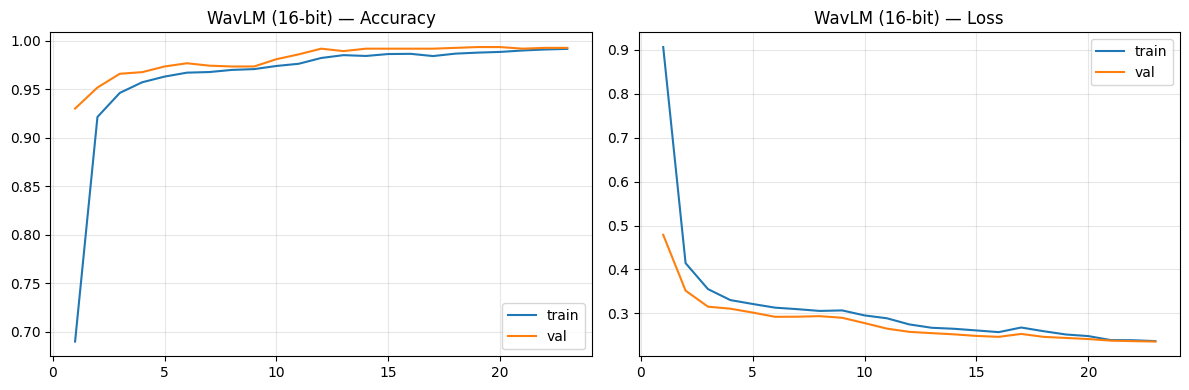

In [15]:
# ============================================================
# [16-bit] 7. Training curves
# ============================================================
hist_df_16 = plot_history(history_16, "WavLM (16-bit)")


WavLM (16-bit) — Test Set Performance
Accuracy   : 0.9942
Precision  : 0.9942
Recall     : 0.9942
F1 (macro) : 0.9942
ROC-AUC    : 0.9999
EER        : 0.0039

              precision    recall  f1-score   support

     Command     0.9967    0.9967    0.9967       300
Conversation     0.9966    0.9867    0.9916       300
     Numeric     0.9967    1.0000    0.9983       300
        Read     0.9868    0.9933    0.9900       300

    accuracy                         0.9942      1200
   macro avg     0.9942    0.9942    0.9942      1200
weighted avg     0.9942    0.9942    0.9942      1200



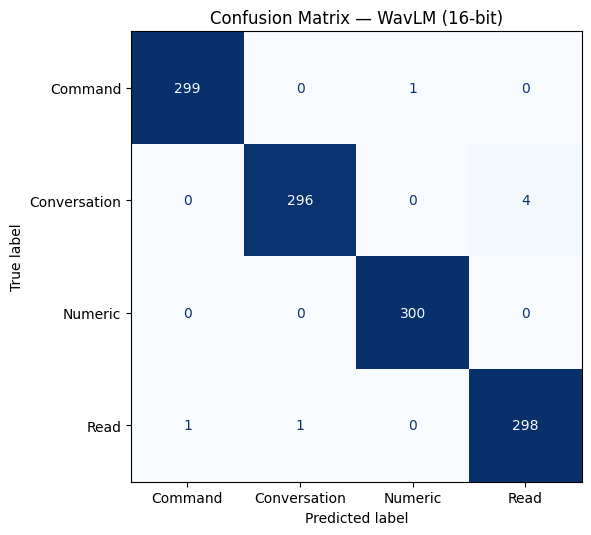

In [16]:
# ============================================================
# [16-bit] 8. Test evaluation (full report)
# ============================================================
report_16bit = full_test_report(model_16bit, test_loader_16, tag="WavLM (16-bit)")


In [17]:
# ============================================================
# [16-bit] 9. MFCC baseline (context for the deep model's gain)
# ============================================================
baseline_16bit = run_mfcc_baseline(X_train_16, y_train_16, X_val_16, y_val_16, X_test_16, y_test_16, tag="16-bit")


[16-bit] MFCC + LogisticRegression baseline — Test Acc: 0.9042 | Macro-F1: 0.9039


In [18]:
# ============================================================
# [16-bit] 10. Free GPU memory before moving to the 1-bit run
# ============================================================
del optimizer_16bit, scheduler_16bit
gc.collect()
torch.cuda.empty_cache()
print("16-bit section complete. Model + best checkpoint retained as `model_16bit` / "
      "'best_wavlm_16bit.pth'.")


16-bit section complete. Model + best checkpoint retained as `model_16bit` / 'best_wavlm_16bit.pth'.


---
# PART B — 1-bit condition
---

In [19]:
# ============================================================
# [1-bit] 1. Load data + sanity checks + de-duplication
# ============================================================
X_train_1, y_train_1 = load_split(DATA1_DIR, "X_1bit_train.npy", "y_1bit_train.npy")
X_val_1, y_val_1 = load_split(DATA1_DIR, "X_1bit_val.npy", "y_1bit_val.npy")
X_test_1, y_test_1 = load_split(DATA1_DIR, "X_1bit_test.npy", "y_1bit_test.npy")

# Match shape convention used elsewhere (N, samples, 1)
X_train_1 = np.squeeze(X_train_1)[..., np.newaxis]
X_val_1 = np.squeeze(X_val_1)[..., np.newaxis]
X_test_1 = np.squeeze(X_test_1)[..., np.newaxis]

describe_dataset("1-bit", X_train_1, y_train_1, X_val_1, y_val_1, X_test_1, y_test_1)
check_leakage(X_train_1, X_val_1, X_test_1)
X_train_1, y_train_1 = dedupe_train_against_val_test(X_train_1, y_train_1, X_val_1, X_test_1, tag="1-bit")


Dataset: 1-bit
Train: (9600, 16000, 1) (9600,)
Val  : (1200, 16000, 1) (1200,)
Test : (1200, 16000, 1) (1200,)
dtype: float32 | min: -1.0 | max: 1.0
train class distribution: {'Command': 2400, 'Conversation': 2400, 'Numeric': 2400, 'Read': 2400}
val class distribution: {'Command': 300, 'Conversation': 300, 'Numeric': 300, 'Read': 300}
test class distribution: {'Command': 300, 'Conversation': 300, 'Numeric': 300, 'Read': 300}
Duplicate waveforms train∩val : 0
Duplicate waveforms train∩test: 1
Duplicate waveforms val∩test  : 0
[1-bit] Removed 5 train sample(s) that duplicated a val/test waveform.


In [20]:
# ============================================================
# [1-bit] 2. DataLoaders
# ============================================================
train_loader_1, val_loader_1, test_loader_1 = make_loaders(
    X_train_1, y_train_1, X_val_1, y_val_1, X_test_1, y_test_1
)

waveforms, labels = next(iter(train_loader_1))
print("Waveforms:", waveforms.shape, waveforms.dtype)
print("Labels   :", labels.shape, labels.dtype)


Waveforms: torch.Size([8, 16000]) torch.float32
Labels   : torch.Size([8]) torch.int64


In [21]:
# ============================================================
# [1-bit] 3. Model
# ============================================================
seed_everything(SEED)
model_1bit = WavLMClassifier(PRETRAINED_CKPT, NUM_CLASSES).to(device)
criterion_1bit = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

best_val_acc_1 = 0.0
best_state_1 = None
history_1 = []
global_epoch_1 = 0


Some weights of the model checkpoint at microsoft/wavlm-base-plus were not used when initializing WavLMModel: ['encoder.pos_conv_embed.conv.weight_g', 'encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing WavLMModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing WavLMModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of WavLMModel were not initialized from the model checkpoint at microsoft/wavlm-base-plus and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictio

In [22]:
# ============================================================
# [1-bit] 4. Stage 1 — classifier head only
# ============================================================
stage = 1
n_unfrozen, max_epochs, lr, patience = STAGES[stage - 1]

model_1bit.unfreeze_top_layers(n_unfrozen)
trainable, total = model_1bit.trainable_param_summary()
print(f"[1-bit] Stage {stage}: unfreeze last {n_unfrozen} layers | trainable {trainable:,} / {total:,}")

optimizer_1bit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_1bit.parameters()), lr=lr, weight_decay=WEIGHT_DECAY
)
n_steps = max_epochs * len(train_loader_1)
scheduler_1bit = get_cosine_schedule_with_warmup(
    optimizer_1bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_1bit, train_loader_1, optimizer_1bit, criterion_1bit, scheduler_1bit)
    va_loss, va_acc = evaluate(model_1bit, val_loader_1, criterion_1bit)
    global_epoch_1 += 1

    print(f"[1-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_1.append({"global_epoch": global_epoch_1, "stage": stage,
                       "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_1:
        best_val_acc_1 = va_acc
        best_state_1 = copy.deepcopy(model_1bit.state_dict())
        torch.save(best_state_1, os.path.join(OUT_DIR, "best_wavlm_1bit.pth"))
        patience_counter = 0
        print(f"  -> new best (Val Acc = {best_val_acc_1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("  -> early stopping stage", stage)
            break

print(f"\n[1-bit] Stage 1 finished. Best Val Acc so far: {best_val_acc_1:.4f}")


[1-bit] Stage 1: unfreeze last 0 layers | trainable 1,184,274 / 95,566,210
[1-bit] Stage 1 Epoch 1/8 | Train Loss 0.9836 Acc 0.6023 | Val Loss 0.7789 Acc 0.7042
  -> new best (Val Acc = 0.7042)
[1-bit] Stage 1 Epoch 2/8 | Train Loss 0.7058 Acc 0.7501 | Val Loss 0.7289 Acc 0.7658
  -> new best (Val Acc = 0.7658)
[1-bit] Stage 1 Epoch 3/8 | Train Loss 0.6737 Acc 0.7675 | Val Loss 0.6827 Acc 0.7667
  -> new best (Val Acc = 0.7667)
[1-bit] Stage 1 Epoch 4/8 | Train Loss 0.6308 Acc 0.7979 | Val Loss 0.6943 Acc 0.7675
  -> new best (Val Acc = 0.7675)
[1-bit] Stage 1 Epoch 5/8 | Train Loss 0.6108 Acc 0.8040 | Val Loss 0.6414 Acc 0.7917
  -> new best (Val Acc = 0.7917)
[1-bit] Stage 1 Epoch 6/8 | Train Loss 0.6066 Acc 0.8114 | Val Loss 0.6532 Acc 0.7925
  -> new best (Val Acc = 0.7925)
[1-bit] Stage 1 Epoch 7/8 | Train Loss 0.5948 Acc 0.8178 | Val Loss 0.6335 Acc 0.8017
  -> new best (Val Acc = 0.8017)
[1-bit] Stage 1 Epoch 8/8 | Train Loss 0.5905 Acc 0.8176 | Val Loss 0.6354 Acc 0.8067
  -> n

In [23]:
# ============================================================
# [1-bit] 5. Stage 2 — unfreeze last 4 transformer layers
# ============================================================
stage = 2
n_unfrozen, max_epochs, lr, patience = STAGES[stage - 1]

model_1bit.load_state_dict(best_state_1)
model_1bit.unfreeze_top_layers(n_unfrozen)
trainable, total = model_1bit.trainable_param_summary()
print(f"[1-bit] Stage {stage}: unfreeze last {n_unfrozen} layers | trainable {trainable:,} / {total:,}")

optimizer_1bit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_1bit.parameters()), lr=lr, weight_decay=WEIGHT_DECAY
)
n_steps = max_epochs * len(train_loader_1)
scheduler_1bit = get_cosine_schedule_with_warmup(
    optimizer_1bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_1bit, train_loader_1, optimizer_1bit, criterion_1bit, scheduler_1bit)
    va_loss, va_acc = evaluate(model_1bit, val_loader_1, criterion_1bit)
    global_epoch_1 += 1

    print(f"[1-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_1.append({"global_epoch": global_epoch_1, "stage": stage,
                       "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_1:
        best_val_acc_1 = va_acc
        best_state_1 = copy.deepcopy(model_1bit.state_dict())
        torch.save(best_state_1, os.path.join(OUT_DIR, "best_wavlm_1bit.pth"))
        patience_counter = 0
        print(f"  -> new best (Val Acc = {best_val_acc_1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("  -> early stopping stage", stage)
            break

print(f"\n[1-bit] Stage 2 finished. Best Val Acc so far: {best_val_acc_1:.4f}")


[1-bit] Stage 2: unfreeze last 4 layers | trainable 29,537,890 / 95,566,210
[1-bit] Stage 2 Epoch 1/10 | Train Loss 0.5910 Acc 0.8155 | Val Loss 0.6120 Acc 0.8100
  -> new best (Val Acc = 0.8100)
[1-bit] Stage 2 Epoch 2/10 | Train Loss 0.5751 Acc 0.8255 | Val Loss 0.6170 Acc 0.8125
  -> new best (Val Acc = 0.8125)
[1-bit] Stage 2 Epoch 3/10 | Train Loss 0.5585 Acc 0.8349 | Val Loss 0.6031 Acc 0.8192
  -> new best (Val Acc = 0.8192)
[1-bit] Stage 2 Epoch 4/10 | Train Loss 0.5534 Acc 0.8370 | Val Loss 0.6031 Acc 0.8142
[1-bit] Stage 2 Epoch 5/10 | Train Loss 0.5413 Acc 0.8422 | Val Loss 0.6108 Acc 0.8125
[1-bit] Stage 2 Epoch 6/10 | Train Loss 0.5380 Acc 0.8444 | Val Loss 0.6134 Acc 0.8100
[1-bit] Stage 2 Epoch 7/10 | Train Loss 0.5179 Acc 0.8540 | Val Loss 0.6121 Acc 0.8133
  -> early stopping stage 2

[1-bit] Stage 2 finished. Best Val Acc so far: 0.8192


In [24]:
# ============================================================
# [1-bit] 6. Stage 3 — unfreeze last 8 transformer layers
# ============================================================
stage = 3
n_unfrozen, max_epochs, lr, patience = STAGES[stage - 1]

model_1bit.load_state_dict(best_state_1)
model_1bit.unfreeze_top_layers(n_unfrozen)
trainable, total = model_1bit.trainable_param_summary()
print(f"[1-bit] Stage {stage}: unfreeze last {n_unfrozen} layers | trainable {trainable:,} / {total:,}")

optimizer_1bit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_1bit.parameters()), lr=lr, weight_decay=WEIGHT_DECAY
)
n_steps = max_epochs * len(train_loader_1)
scheduler_1bit = get_cosine_schedule_with_warmup(
    optimizer_1bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_1bit, train_loader_1, optimizer_1bit, criterion_1bit, scheduler_1bit)
    va_loss, va_acc = evaluate(model_1bit, val_loader_1, criterion_1bit)
    global_epoch_1 += 1

    print(f"[1-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_1.append({"global_epoch": global_epoch_1, "stage": stage,
                       "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_1:
        best_val_acc_1 = va_acc
        best_state_1 = copy.deepcopy(model_1bit.state_dict())
        torch.save(best_state_1, os.path.join(OUT_DIR, "best_wavlm_1bit.pth"))
        patience_counter = 0
        print(f"  -> new best (Val Acc = {best_val_acc_1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("  -> early stopping stage", stage)
            break

model_1bit.load_state_dict(best_state_1)
print(f"\n[1-bit] All stages finished. Best Validation Accuracy: {best_val_acc_1:.4f}")


[1-bit] Stage 3: unfreeze last 8 layers | trainable 57,891,506 / 95,566,210
[1-bit] Stage 3 Epoch 1/8 | Train Loss 0.5515 Acc 0.8368 | Val Loss 0.5736 Acc 0.8233
  -> new best (Val Acc = 0.8233)
[1-bit] Stage 3 Epoch 2/8 | Train Loss 0.5325 Acc 0.8442 | Val Loss 0.5916 Acc 0.8150
[1-bit] Stage 3 Epoch 3/8 | Train Loss 0.5112 Acc 0.8568 | Val Loss 0.5877 Acc 0.8292
  -> new best (Val Acc = 0.8292)
[1-bit] Stage 3 Epoch 4/8 | Train Loss 0.5009 Acc 0.8624 | Val Loss 0.5854 Acc 0.8225
[1-bit] Stage 3 Epoch 5/8 | Train Loss 0.4795 Acc 0.8779 | Val Loss 0.5567 Acc 0.8400
  -> new best (Val Acc = 0.8400)
[1-bit] Stage 3 Epoch 6/8 | Train Loss 0.4770 Acc 0.8734 | Val Loss 0.5722 Acc 0.8325
[1-bit] Stage 3 Epoch 7/8 | Train Loss 0.4694 Acc 0.8788 | Val Loss 0.6034 Acc 0.8183
[1-bit] Stage 3 Epoch 8/8 | Train Loss 0.4653 Acc 0.8816 | Val Loss 0.6002 Acc 0.8217

[1-bit] All stages finished. Best Validation Accuracy: 0.8400


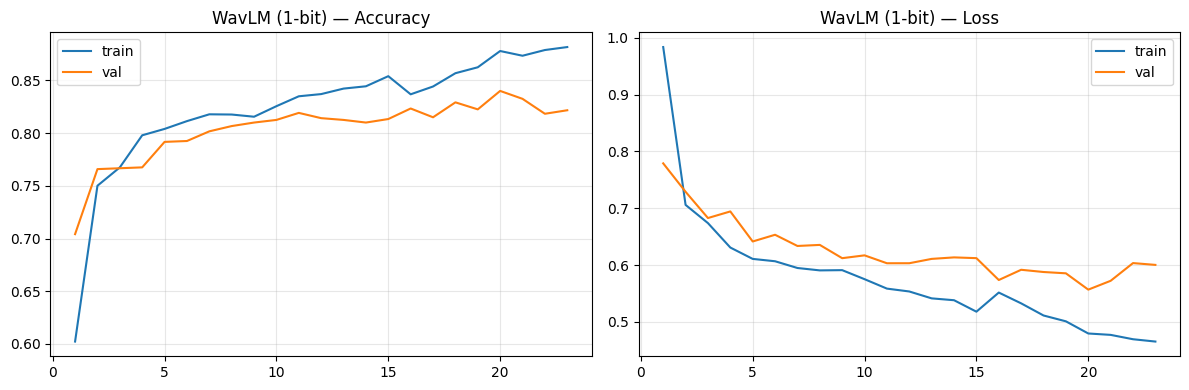

In [25]:
# ============================================================
# [1-bit] 7. Training curves
# ============================================================
hist_df_1 = plot_history(history_1, "WavLM (1-bit)")


WavLM (1-bit) — Test Set Performance
Accuracy   : 0.8567
Precision  : 0.8689
Recall     : 0.8567
F1 (macro) : 0.8555
ROC-AUC    : 0.9677
EER        : 0.0756

              precision    recall  f1-score   support

     Command     0.8187    0.9333    0.8723       300
Conversation     0.9352    0.6733    0.7829       300
     Numeric     0.9932    0.9800    0.9866       300
        Read     0.7283    0.8400    0.7802       300

    accuracy                         0.8567      1200
   macro avg     0.8689    0.8567    0.8555      1200
weighted avg     0.8689    0.8567    0.8555      1200



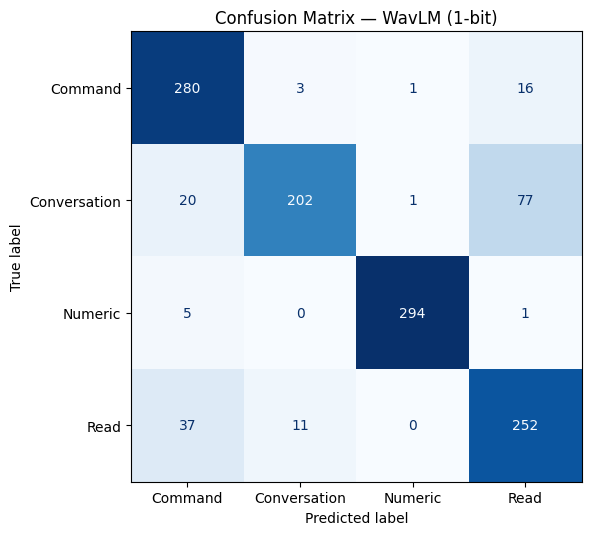

In [26]:
# ============================================================
# [1-bit] 8. Test evaluation (full report)
# ============================================================
report_1bit = full_test_report(model_1bit, test_loader_1, tag="WavLM (1-bit)")


In [27]:
# ============================================================
# [1-bit] 9. MFCC baseline
# ============================================================
baseline_1bit = run_mfcc_baseline(X_train_1, y_train_1, X_val_1, y_val_1, X_test_1, y_test_1, tag="1-bit")


[1-bit] MFCC + LogisticRegression baseline — Test Acc: 0.8258 | Macro-F1: 0.8252


---
# Final comparison — 16-bit vs 1-bit (WavLM)
---

In [28]:
# ============================================================
# Comparison — bootstrap CI + McNemar test + results table
# ============================================================
def bootstrap_ci_paired(labels, preds, metric_fn, n_boot=2000, seed=0):
    rng = np.random.RandomState(seed)
    n = len(labels)
    stats = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        stats.append(metric_fn(labels[idx], preds[idx]))
    lo, hi = np.percentile(stats, [2.5, 97.5])
    return float(np.mean(stats)), float(lo), float(hi)


def mcnemar_test(labels, preds_a, preds_b):
    correct_a = (preds_a == labels)
    correct_b = (preds_b == labels)
    n01 = int(np.sum(correct_a & ~correct_b))
    n10 = int(np.sum(~correct_a & correct_b))
    if n01 + n10 == 0:
        return 1.0
    stat = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
    return 1 - chi2.cdf(stat, df=1)


acc_ci_16 = bootstrap_ci_paired(report_16bit["labels"], report_16bit["preds"], accuracy_score)
acc_ci_1 = bootstrap_ci_paired(report_1bit["labels"], report_1bit["preds"], accuracy_score)

print(f"16-bit test accuracy 95% bootstrap CI: mean={acc_ci_16[0]:.4f} [{acc_ci_16[1]:.4f}, {acc_ci_16[2]:.4f}]")
print(f"1-bit  test accuracy 95% bootstrap CI: mean={acc_ci_1[0]:.4f} [{acc_ci_1[1]:.4f}, {acc_ci_1[2]:.4f}]")

if len(report_16bit["labels"]) == len(report_1bit["labels"]):
    p_val = mcnemar_test(report_16bit["labels"], report_16bit["preds"], report_1bit["preds"])
    print(f"McNemar test (16-bit vs 1-bit predictions), p-value = {p_val:.4g}")
else:
    print("Test sets differ in size/order — McNemar test needs matched items, skipping.")

final_table = pd.DataFrame([
    {"Model": "MFCC + LogisticRegression", "Condition": "16-bit",
     "Accuracy": baseline_16bit["accuracy"], "Macro-F1": baseline_16bit["macro_f1"]},
    {"Model": "MFCC + LogisticRegression", "Condition": "1-bit",
     "Accuracy": baseline_1bit["accuracy"], "Macro-F1": baseline_1bit["macro_f1"]},
    {"Model": "WavLM (this run)", "Condition": "16-bit",
     "Accuracy": report_16bit["accuracy"], "Macro-F1": report_16bit["f1_macro"]},
    {"Model": "WavLM (this run)", "Condition": "1-bit",
     "Accuracy": report_1bit["accuracy"], "Macro-F1": report_1bit["f1_macro"]},
])
print(final_table.to_string(index=False))

final_table.to_csv(os.path.join(OUT_DIR, "final_results_table_wavlm.csv"), index=False)
hist_df_16.to_csv(os.path.join(OUT_DIR, "history_16bit_wavlm.csv"), index=False)
hist_df_1.to_csv(os.path.join(OUT_DIR, "history_1bit_wavlm.csv"), index=False)
print(f"\nArtifacts written to: {OUT_DIR}")


16-bit test accuracy 95% bootstrap CI: mean=0.9942 [0.9892, 0.9983]
1-bit  test accuracy 95% bootstrap CI: mean=0.8570 [0.8375, 0.8758]
McNemar test (16-bit vs 1-bit predictions), p-value = 0
                    Model Condition  Accuracy  Macro-F1
MFCC + LogisticRegression    16-bit  0.904167  0.903917
MFCC + LogisticRegression     1-bit  0.825833  0.825150
         WavLM (this run)    16-bit  0.994167  0.994165
         WavLM (this run)     1-bit  0.856667  0.855496

Artifacts written to: /kaggle/working/results_wavlm


## Reporting checklist

- [ ] Confirm the de-duplication cell actually reports 0 removed for 16-bit and (if the
      earlier 1-bit duplicate exists in this dataset copy too) exactly 1 removed for
      1-bit — that tells you whether the raw `.npy` files themselves were fixed since
      your wav2vec2 run.
- [ ] Rerun with `Kernel → Restart & Run All` and don't manually re-execute individual
      stage cells — this is what makes the reported "best val acc" values traceable to
      an actual printed epoch.
- [ ] Report the MFCC baseline and — if available — the wav2vec2 numbers from your
      earlier notebook alongside these, so a reader can see WavLM's gain over both a
      non-pretrained baseline and a same-size pretrained alternative.
- [ ] If WavLM does meaningfully better on 1-bit than wav2vec2 did, that supports the
      "utterance mixing" pretraining hypothesis from the intro — say so, but only after
      confirming it holds across a few seeds, not one run.
- [ ] Same seed-variance and bootstrap-CI caveats as before apply here — one run is a
      data point, not a result.
